<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2/03_predicting_price_and_quantities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Prices and Quantities with Product Embeddings

This notebook is the third of five labs that accompany [Bach et al. (2025)](https://arxiv.org/abs/2501.00382). It requires the embeddings saved in **Lab 2**.

Before we estimate a causal effect, it is useful to know what the controls can predict. In the partially linear model of Lab 4,

$$Q_{it}^{\perp} = \delta\, P_{it}^{\perp} + e_{it}, \qquad
Q^{\perp}_{it} := Q_{it} - E[Q_{it}\mid S_{it}], \quad
P^{\perp}_{it} := P_{it} - E[P_{it}\mid S_{it}],$$

everything rests on the two nuisance functions $E[Q\mid S]$ and $E[P\mid S]$. In this lab, we measure how well we can estimate them and which kind of variation the fine-tuned embeddings explain.

## Four Prediction Targets

We consider the levels and the changes of both signals:

| Target | Meaning |
|---|---|
| $Q_{it}$ | level of the quantity signal |
| $P_{it}$ | level of the price signal |
| $\Delta Q_{it}$ | period-to-period change in the quantity signal |
| $\Delta P_{it}$ | period-to-period change in the price signal |

A confounder of the price-quantity relationship has to explain changes, since it must move price and quantity together over time. A variable that only explains levels, that is, why one product is generally more expensive or sells better than another, is largely absorbed by the product's own history and does not bias the elasticity much. It can still tell us for which products the elasticity is large or small.

The gap between levels and changes therefore determines whether the embeddings act as confounders, which is the concern of Lab 4, or as effect modifiers, which is the topic of Lab 5.

We fit all models on the fine-tuning products and evaluate them on the estimation products, which are entirely held out. Following the paper, we report negative out-of-sample $R^2$ values as 0.

First, we install and load the required packages.

In [1]:
%pip install -q lightgbm

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

palette = sns.color_palette("colorblind")
pd.set_option("display.width", 140)

## Data

We load the data saved in Lab 2 from Google Drive. If the file is not found there, the cell also looks for a copy uploaded to the current session.

In [3]:
ARTIFACT = "subsample_v2.parquet"
drive_path = f"/content/drive/MyDrive/demand_labs_v2/{ARTIFACT}"

# Colab gives every notebook its own machine, so /content does not carry across
# labs. Google Drive does.
if os.path.isdir("/content") and not os.path.exists(drive_path):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"could not mount Drive ({type(exc).__name__})")

path = next((p for p in [drive_path, f"/content/{ARTIFACT}", ARTIFACT]
             if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(
        "subsample_v2.parquet not found. Run Lab 2 "
        "(02_finetune_embeddings.ipynb) first and let it save to Google Drive, "
        "or upload the file into this session.")

df = pd.read_parquet(path)
print(f"loaded {path}")
print(f"{df['ASIN'].nunique():,} products, {len(df):,} rows, "
      f"{df['period'].nunique()} periods")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size")))

Mounted at /content/drive
loaded /content/drive/MyDrive/demand_labs_v2/subsample_v2.parquet
1,540 products, 21,560 rows, 14 periods
            products   rows
split                      
estimation       770  10780
finetune         770  10780


The data contain 1,540 products observed in 14 periods, split evenly into 770 fine-tuning and 770 estimation products.

## Feature Sets

Following Tables 5 and 6 of the paper, we consider four nested specifications:

* **Tabular**: human-coded features only, that is, subcategory and period dummies and the time-varying controls, but no embeddings.
* **+ 5 PCA**: adds the first five principal components of $X^e$.
* **+ 5 Similarities**: adds the five cosine similarities to the $k$-means centroids.
* **+ 256 Embeddings**: adds the full projected embedding.

All four include the time-varying tabular controls (lagged rating and review count, offer counts, deal and FBA indicators). We estimate each specification twice: once without lagged $Q$ and $P$, which corresponds to the comparison in Tables 5 and 6 of the paper, and once with them, which corresponds to the full state $S_{it}$ that Lab 4 conditions on. The contrast between the two is the main point of this lab.

In [4]:
emb_cols = [c for c in df.columns if c.startswith("emb_")]
pca_cols = [c for c in df.columns if c.startswith("pca_")]
sim_cols = [c for c in df.columns if c.startswith("similarity_cluster_")]
sub_cols = [c for c in df.columns if c.startswith("sub_")]

lag_controls = ["Q_t-1", "P_bb_t-1"]
tab_controls = ["RATING_t-1", "REVIEW_COUNT_t-1", "n_offers",
                "n_offers_fba", "n_offers_fbm", "lightning_deal", "is_fba"]

periods = sorted(df["period"].unique())[1:]   # first period is the baseline
period_cols = [f"period_{p}" for p in periods]
for p in periods:
    df[f"period_{p}"] = (df["period"] == p).astype(int)

BASE = sub_cols + period_cols + tab_controls
FEATURE_SETS = {
    "Tabular":          BASE,
    "+ 5 PCA":          BASE + pca_cols,
    "+ 5 Similarities": BASE + sim_cols,
    "+ 256 Embeddings": BASE + emb_cols,
}
STATE = lag_controls + tab_controls   # dropna basis: same rows for every spec
TARGETS = ["Q_t", "P_bb_t", "Delta_Q_t", "Delta_P_bb_t"]

print(f"{len(emb_cols)} embeddings | {len(pca_cols)} PCA | {len(sim_cols)} "
      f"similarities | {len(sub_cols)} subcategories | {len(period_cols)} periods")

256 embeddings | 5 PCA | 5 similarities | 11 subcategories | 13 periods


## Estimation

For every combination of feature set, lag specification and target, we fit a linear regression by OLS and gradient boosted trees (LightGBM). The first period of each product has no lagged values and is dropped throughout, so every specification is evaluated on the same observations.

In [5]:
data = df.dropna(subset=STATE + TARGETS).copy()
train = data[data["split"] == "finetune"]
test = data[data["split"] == "estimation"]
print(f"train: {len(train):,} rows ({train['ASIN'].nunique()} products)   "
      f"test: {len(test):,} rows ({test['ASIN'].nunique()} products)")


def score(features, target):
    """Out-of-sample R^2 for OLS and LightGBM; negatives clipped to 0."""
    X_tr, X_te = train[features], test[features]
    y_tr, y_te = train[target], test[target]

    ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
    r2_ols = r2_score(y_te, ols.predict(sm.add_constant(X_te, has_constant="add")))

    gbm = LGBMRegressor(n_estimators=500, learning_rate=0.02,
                        random_state=42, verbose=-1).fit(X_tr, y_tr)
    r2_gbm = r2_score(y_te, gbm.predict(X_te))

    return {"OLS": max(r2_ols, 0.0), "LightGBM": max(r2_gbm, 0.0)}


rows = []
for with_lags in (False, True):
    label = "with lagged Q,P" if with_lags else "no lagged Q,P"
    for name, feats in FEATURE_SETS.items():
        cols = feats + (lag_controls if with_lags else [])
        for target in TARGETS:
            for model, value in score(cols, target).items():
                rows.append({"Controls": label, "Features": name, "Model": model,
                             "Target": target, "R2": value})
        print(f"  {label:13s} | {name:18s} done", flush=True)

results = pd.DataFrame(rows)

train: 10,010 rows (770 products)   test: 10,010 rows (770 products)


/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  no lagged Q,P | Tabular            done


/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  no lagged Q,P | + 5 PCA            done


...

  with lagged Q,P | + 5 PCA            done


/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  with lagged Q,P | + 5 Similarities   done


/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()
/tmp/ipykernel_2351/1498864721.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(y_tr, sm.add_constant(X_tr, has_constant="add")).fit()


  with lagged Q,P | + 256 Embeddings   done


## Results

Both the training and the test sample contain 10,010 observations of 770 products each. The table reports the out-of-sample $R^2$ in percent, and the figure below shows the LightGBM results graphically.

**Note:** The `SingularMatrixWarning`s above indicate that the OLS design matrix is rank-deficient, since the full set of subcategory dummies is collinear with the constant. `statsmodels` then uses a pseudo-inverse, and the predictions remain well defined.

In [6]:
table = (results
         .pivot_table(index=["Controls", "Features", "Model"], columns="Target",
                      values="R2")
         .reindex(columns=TARGETS)
         .reindex(["no lagged Q,P", "with lagged Q,P"], level="Controls")
         .reindex(list(FEATURE_SETS), level="Features"))
print("Out-of-sample R^2 (%)")
(table * 100).round(2)

Out-of-sample R^2 (%)


Target                                       Q_t  P_bb_t  Delta_Q_t  Delta_P_bb_t
Controls        Features         Model                                           
no lagged Q,P   Tabular          LightGBM  52.39    0.84       8.97          0.00
                                 OLS       24.35    8.72       5.24          0.69
                + 5 PCA          LightGBM  56.13   43.62       8.17          0.00
                                 OLS       50.20   45.99       5.23          0.64
                + 5 Similarities LightGBM  55.91   41.80       8.18          0.00
                                 OLS       50.48   42.85       5.23          0.64
                + 256 Embeddings LightGBM  53.15   41.54       6.81          0.00
                                 OLS       44.97   38.14       3.51          0.00
with lagged Q,P Tabular          LightGBM  92.47   95.68      13.31          0.00
                                 OLS       92.17   97.43       8.10          1.69
                + 5 PCA          LightGBM  91.55   95.00       1.07          0.00
                                 OLS       91.71   97.36       2.72          0.00
                + 5 Similarities LightGBM  91.46   94.99       1.51          0.00
                                 OLS       91.73   97.37       2.93          0.00
                + 256 Embeddings LightGBM  90.59   95.67       0.00          0.00
                                 OLS       89.57   96.88       0.00          0.00

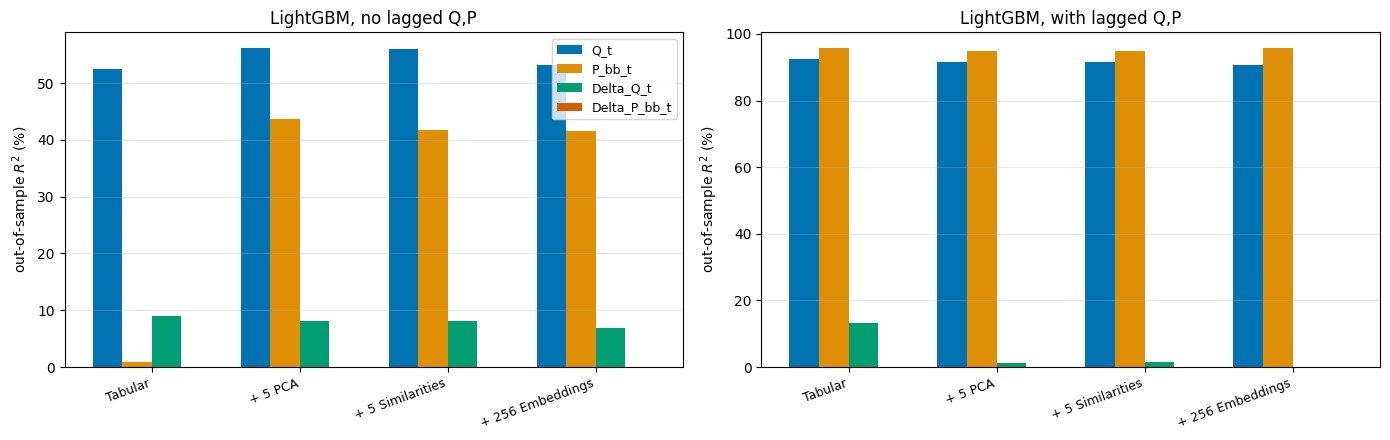

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, state in zip(axes, ["no lagged Q,P", "with lagged Q,P"]):
    sub = results[(results["Controls"] == state) & (results["Model"] == "LightGBM")]
    wide = sub.pivot(index="Features", columns="Target",
                     values="R2").reindex(list(FEATURE_SETS))
    x = np.arange(len(wide))
    for i, t in enumerate(TARGETS):
        ax.bar(x + (i - 1.5) * 0.2, wide[t] * 100, 0.2, label=t, color=palette[i])
    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("out-of-sample $R^2$ (%)")
    ax.set_title(f"LightGBM, {state}")
    ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

### Levels versus Changes

To see the asymmetry directly, we compute how much the 256 embeddings add to the tabular baseline for each target.

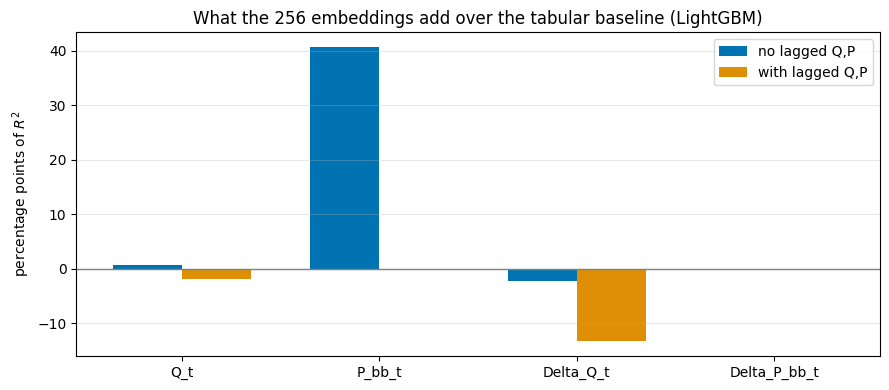

Target            Q_t  P_bb_t  Delta_Q_t  Delta_P_bb_t
Controls                                              
no lagged Q,P    0.76   40.70      -2.16           0.0
with lagged Q,P -1.88   -0.01     -13.31           0.0


In [8]:
gain = (results[results["Model"] == "LightGBM"]
        .pivot_table(index=["Controls", "Features"], columns="Target", values="R2"))
delta = (gain.xs("+ 256 Embeddings", level="Features")
         - gain.xs("Tabular", level="Features"))[TARGETS]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(TARGETS))
for i, state in enumerate(["no lagged Q,P", "with lagged Q,P"]):
    ax.bar(x + (i - 0.5) * 0.35, delta.loc[state] * 100, 0.35,
           label=state, color=palette[i])
ax.axhline(0, color="gray", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(TARGETS)
ax.set_ylabel("percentage points of $R^2$")
ax.set_title("What the 256 embeddings add over the tabular baseline (LightGBM)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print((delta * 100).round(2).to_string())

## Discussion

**Without lagged $Q$ and $P$, the embeddings mainly help to predict the price level.** With tabular features only, LightGBM reaches an out-of-sample $R^2$ of 52.4% for $Q_{it}$ but only 0.8% for $P_{it}$ (8.7% with OLS). Adding the embeddings raises the $R^2$ for $P_{it}$ to between 38% and 46%, an increase of 40.7 percentage points for LightGBM with the 256 embeddings. For $Q_{it}$, the gain is small for LightGBM (from 52.4% to at most 56.1%) but large for OLS (from 24.4% to between 45% and 50%). A subcategory label is a coarse summary of a product, and the description and the image carry much of the information that determines its price.

**Five summaries do about as well as 256 dimensions.** The five principal components and the five cluster similarities perform about as well as, and often better than, the full 256-dimensional embedding. This is what allows Lab 5 to use five similarities as effect modifiers: the heterogeneity model remains small enough to interpret without discarding much information.

**Neither learner dominates.** Without lags, LightGBM predicts $Q_{it}$ and $\Delta Q_{it}$ better than OLS, whereas OLS predicts $P_{it}$ better in most specifications.

**Changes are much harder to predict than levels.** No specification explains more than 13.3% of the variation in $\Delta Q_{it}$ or more than 1.7% of the variation in $\Delta P_{it}$. The paper finds the same pattern in the full sample, where the best models reach roughly 50% to 60% $R^2$ for $Q_{it}$ and 65% for $P_{it}$, but only about 15% for $\Delta Q_{it}$ and 1.5% for $\Delta P_{it}$.

**Once the lagged state is included, the embeddings no longer help.** With lagged $Q$ and $P$ in the model, the tabular baseline already reaches 92.5% for $Q_{it}$ and 95.7% for $P_{it}$ with LightGBM, and adding the embeddings changes these numbers by less than 2 percentage points. For $\Delta Q_{it}$, the 256 embeddings even lower the $R^2$ of LightGBM from 13.3% to 0%, since the additional features lead to overfitting. The lagged quantity $Q_{i,t-1}$ already reflects how popular and how visible a product is, which is most of what the description and the image tell us. This is the paper's finding that lagged quantity is the key confounder, and it is the reason why Lab 4 builds its state around it.

### Implications for Labs 4 and 5

A variable confounds the price-quantity relationship only if it moves both. The embeddings barely predict $\Delta P_{it}$: knowing what a product is tells us little about when its price will change. Adding them as controls should therefore leave the estimated elasticity roughly unchanged, which is what we find in Lab 4.

What the embeddings do predict are levels, in particular which products are expensive. Such characteristics are plausible determinants of how strongly the demand for a product reacts to a price change, so Lab 5 lets the elasticity depend on them.

**Note:**

* The estimation sample here is roughly a quarter of the size of the paper's, so the $R^2$ values are noisier than the published ones, and adjacent rows may switch order. The gap between levels and changes is large enough to survive this.
* OLS with the 256-dimensional embedding is fitted on only 770 products and can overfit badly enough to produce a negative out-of-sample $R^2$, which we report as 0. This is a small-sample artifact rather than a finding.
* The numbers depend on the embeddings from Lab 2 and change slightly when Lab 2 is re-run.